# Chapter 4: Training Models

This notebook explores how machine learning models work under the hood, focusing on training algorithms and optimization techniques.

## Topics Covered:
1. Linear Regression (Normal Equation & Gradient Descent)
2. Gradient Descent Variants (Batch, Stochastic, Mini-batch)
3. Polynomial Regression
4. Learning Curves
5. Regularization (Ridge, Lasso, Elastic Net)
6. Logistic Regression
7. Softmax Regression

## Setup: Import Required Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.base import clone

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


---
## 1. Linear Regression Fundamentals

### Theory
Linear Regression makes predictions using a weighted sum of input features:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

In vectorized form:
$$\hat{y} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \boldsymbol{\theta} \cdot \mathbf{x}$$

Where:
- $\hat{y}$ = predicted value
- $\boldsymbol{\theta}$ = parameter vector $[\theta_0, \theta_1, ..., \theta_n]$
- $\mathbf{x}$ = feature vector $[x_0, x_1, ..., x_n]$ where $x_0 = 1$ (bias term)

### Cost Function: Mean Squared Error (MSE)
$$\text{MSE}(\mathbf{X}, h_{\boldsymbol{\theta}}) = \frac{1}{m} \sum_{i=1}^{m} \left(\boldsymbol{\theta}^T \mathbf{x}^{(i)} - y^{(i)}\right)^2$$

### Generate Sample Data
Let's create a simple linear dataset: $y = 4 + 3x + \text{noise}$

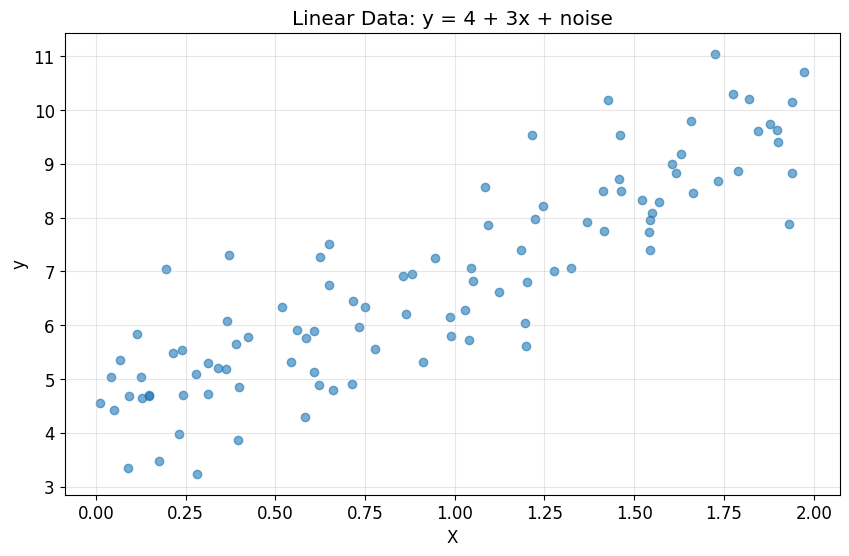

Generated 100 data points
X shape: (100, 1)
y shape: (100, 1)


In [3]:
# Generate linear data
m = 100  # number of instances
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Data: y = 4 + 3x + noise")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Generated {m} data points")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

---
## 2. The Normal Equation

### Theory
The Normal Equation provides a closed-form solution to find the optimal parameters:

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

**Computational Complexity:**
- O(n²·⁴) to O(n³) where n = number of features
- Linear with respect to training instances: O(m)
- Becomes slow with many features (100,000+)

### Implementation from Scratch

In [4]:
# Add x₀ = 1 to each instance (bias term)
X_b = np.c_[np.ones((m, 1)), X]  # concatenate ones column

print("Original X shape:", X.shape)
print("X with bias term shape:", X_b.shape)
print("\nFirst 5 rows of X_b:")
print(X_b[:5])

Original X shape: (100, 1)
X with bias term shape: (100, 2)

First 5 rows of X_b:
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]
 [1.         1.19731697]
 [1.         0.31203728]]


In [5]:
# Compute θ using Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Optimal parameters found by Normal Equation:")
print(f"θ₀ (intercept): {theta_best[0][0]:.4f}")
print(f"θ₁ (slope): {theta_best[1][0]:.4f}")
print(f"\nExpected: θ₀ ≈ 4, θ₁ ≈ 3")

Optimal parameters found by Normal Equation:
θ₀ (intercept): 4.2151
θ₁ (slope): 2.7701

Expected: θ₀ ≈ 4, θ₁ ≈ 3


Predictions:
X = 0: y = 4.2151
X = 2: y = 9.7553


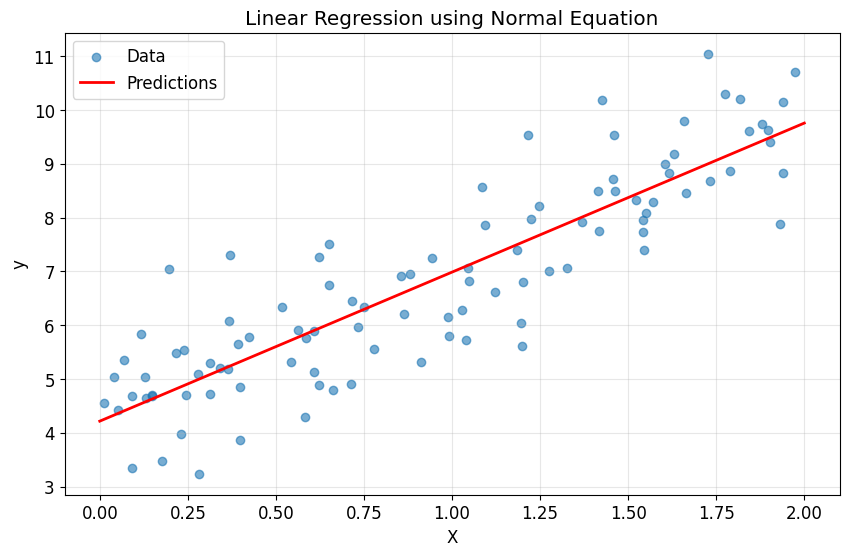

In [6]:
# Make predictions
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add bias term
y_predict = X_new_b.dot(theta_best)

print("Predictions:")
print(f"X = 0: y = {y_predict[0][0]:.4f}")
print(f"X = 2: y = {y_predict[1][0]:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Normal Equation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Using Scikit-Learn's LinearRegression

Scikit-Learn uses **Singular Value Decomposition (SVD)** via `scipy.linalg.lstsq()` for better numerical stability.

In [7]:
# Using Scikit-Learn
lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("Scikit-Learn LinearRegression results:")
print(f"Intercept (θ₀): {lin_reg.intercept_[0]:.4f}")
print(f"Coefficient (θ₁): {lin_reg.coef_[0][0]:.4f}")

# Make predictions
y_predict_sklearn = lin_reg.predict(X_new)
print(f"\nPredictions:")
print(f"X = 0: y = {y_predict_sklearn[0][0]:.4f}")
print(f"X = 2: y = {y_predict_sklearn[1][0]:.4f}")

Scikit-Learn LinearRegression results:
Intercept (θ₀): 4.2151
Coefficient (θ₁): 2.7701

Predictions:
X = 0: y = 4.2151
X = 2: y = 9.7553


---
## 3. Gradient Descent

### Theory
Gradient Descent is an iterative optimization algorithm that tweaks parameters to minimize the cost function.

**Process:**
1. Start with random parameters (random initialization)
2. Compute gradient of cost function
3. Take a step in direction of descending gradient
4. Repeat until convergence

**Update Rule:**
$$\boldsymbol{\theta}^{(\text{next})} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta})$$

Where:
- $\eta$ (eta) = learning rate (controls step size)
- $\nabla_{\boldsymbol{\theta}} \text{MSE}$ = gradient vector

**Key Point:** Always scale features before using Gradient Descent!

### 3.1 Batch Gradient Descent

Uses the **entire training set** to compute gradients at each step.

**Gradient Vector:**
$$\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \mathbf{X}^T (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

In [8]:
# Batch Gradient Descent implementation
eta = 0.1  # learning rate
n_iterations = 1000
m = len(X_b)

# Random initialization
theta = np.random.randn(2, 1)

# Track theta values for visualization
theta_history = [theta.copy()]

for iteration in range(n_iterations):
    # Compute gradient
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    # Update theta
    theta = theta - eta * gradients
    theta_history.append(theta.copy())

print("Batch Gradient Descent results:")
print(f"θ₀ (intercept): {theta[0][0]:.4f}")
print(f"θ₁ (slope): {theta[1][0]:.4f}")
print(f"\nCompare to Normal Equation: θ₀ = {theta_best[0][0]:.4f}, θ₁ = {theta_best[1][0]:.4f}")

Batch Gradient Descent results:
θ₀ (intercept): 4.2151
θ₁ (slope): 2.7701

Compare to Normal Equation: θ₀ = 4.2151, θ₁ = 2.7701


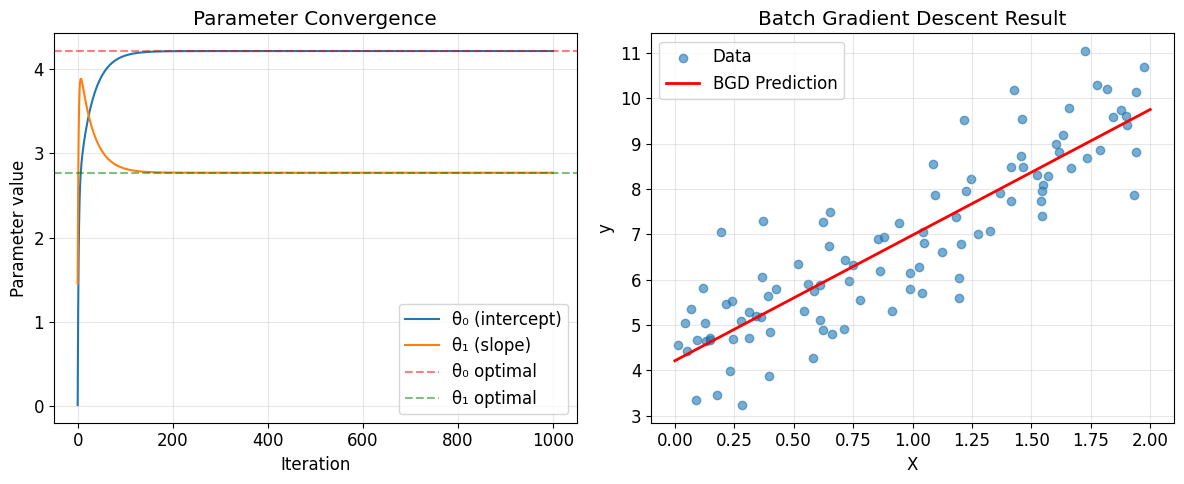

In [9]:
# Visualize convergence
theta_history = np.array(theta_history)

plt.figure(figsize=(12, 5))

# Plot parameter evolution
plt.subplot(1, 2, 1)
plt.plot(theta_history[:, 0], label='θ₀ (intercept)')
plt.plot(theta_history[:, 1], label='θ₁ (slope)')
plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.5, label='θ₀ optimal')
plt.axhline(y=theta_best[1][0], color='g', linestyle='--', alpha=0.5, label='θ₁ optimal')
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Parameter Convergence')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot final fit
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label="Data")
y_predict_gd = X_new_b.dot(theta)
plt.plot(X_new, y_predict_gd, "r-", linewidth=2, label="BGD Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Batch Gradient Descent Result")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Effect of Learning Rate

The learning rate is crucial:
- **Too small:** Slow convergence
- **Too large:** May diverge (oscillate or jump around)
- **Just right:** Converges efficiently

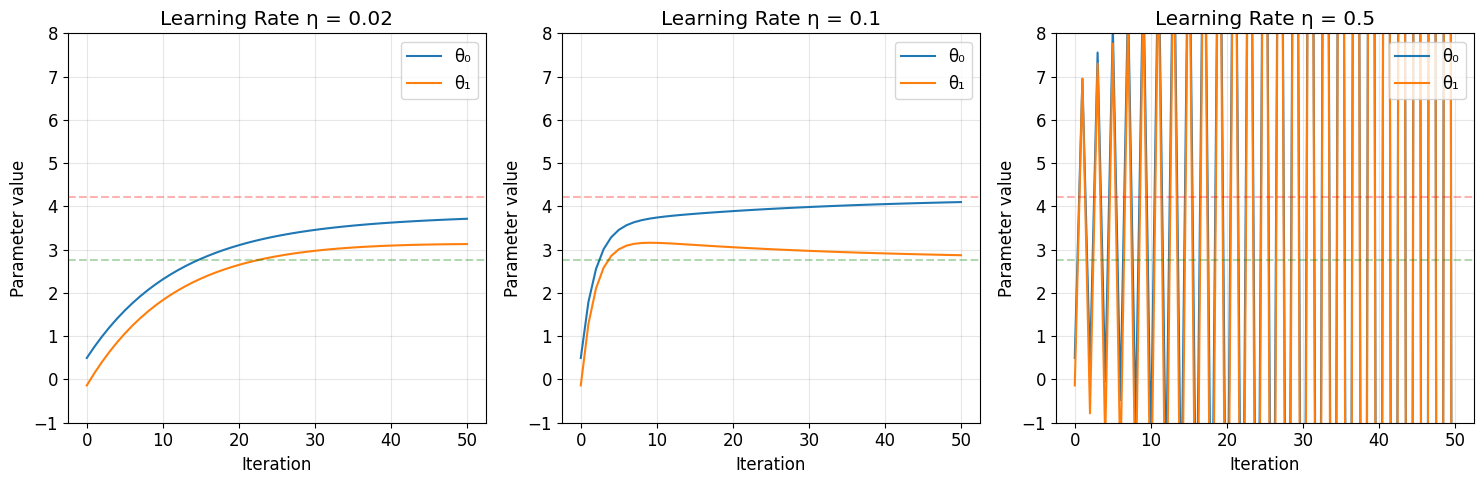

In [10]:
# Compare different learning rates
def batch_gradient_descent(X, y, eta, n_iterations):
    m = len(X)
    theta = np.random.randn(2, 1)
    theta_history = [theta.copy()]
    
    for iteration in range(n_iterations):
        gradients = 2/m * X.T.dot(X.dot(theta) - y)
        theta = theta - eta * gradients
        theta_history.append(theta.copy())
    
    return np.array(theta_history)

learning_rates = [0.02, 0.1, 0.5]
n_iter = 50

plt.figure(figsize=(15, 5))

for idx, eta in enumerate(learning_rates, 1):
    np.random.seed(42)  # Same starting point
    theta_hist = batch_gradient_descent(X_b, y, eta, n_iter)
    
    plt.subplot(1, 3, idx)
    plt.plot(theta_hist[:, 0], label='θ₀')
    plt.plot(theta_hist[:, 1], label='θ₁')
    plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.3)
    plt.axhline(y=theta_best[1][0], color='g', linestyle='--', alpha=0.3)
    plt.xlabel('Iteration')
    plt.ylabel('Parameter value')
    plt.title(f'Learning Rate η = {eta}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-1, 8)

plt.tight_layout()
plt.show()

---
## 3.2 Stochastic Gradient Descent (SGD)

### Theory
SGD picks **one random instance** at each step to compute gradients.

**Advantages:**
- Much faster (less data per iteration)
- Can handle huge datasets (online learning)
- Can escape shallow local minima

**Disadvantages:**
- Irregular path (bounces around)
- Never truly settles at minimum
- Requires learning schedule to converge

**Learning Schedule:** Gradually reduce learning rate over time

In [11]:
# Stochastic Gradient Descent implementation
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

# Random initialization
np.random.seed(42)
theta = np.random.randn(2, 1)
theta_history_sgd = [theta.copy()]

for epoch in range(n_epochs):
    for i in range(m):
        # Pick one random instance
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        
        # Compute gradient for this instance
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        
        # Update with decreasing learning rate
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
        
        if i % 10 == 0:  # Store every 10th step
            theta_history_sgd.append(theta.copy())

theta_history_sgd = np.array(theta_history_sgd)

print("Stochastic Gradient Descent results:")
print(f"θ₀ (intercept): {theta[0][0]:.4f}")
print(f"θ₁ (slope): {theta[1][0]:.4f}")
print(f"\nCompare to optimal: θ₀ = {theta_best[0][0]:.4f}, θ₁ = {theta_best[1][0]:.4f}")

Stochastic Gradient Descent results:
θ₀ (intercept): 4.2108
θ₁ (slope): 2.7486

Compare to optimal: θ₀ = 4.2151, θ₁ = 2.7701


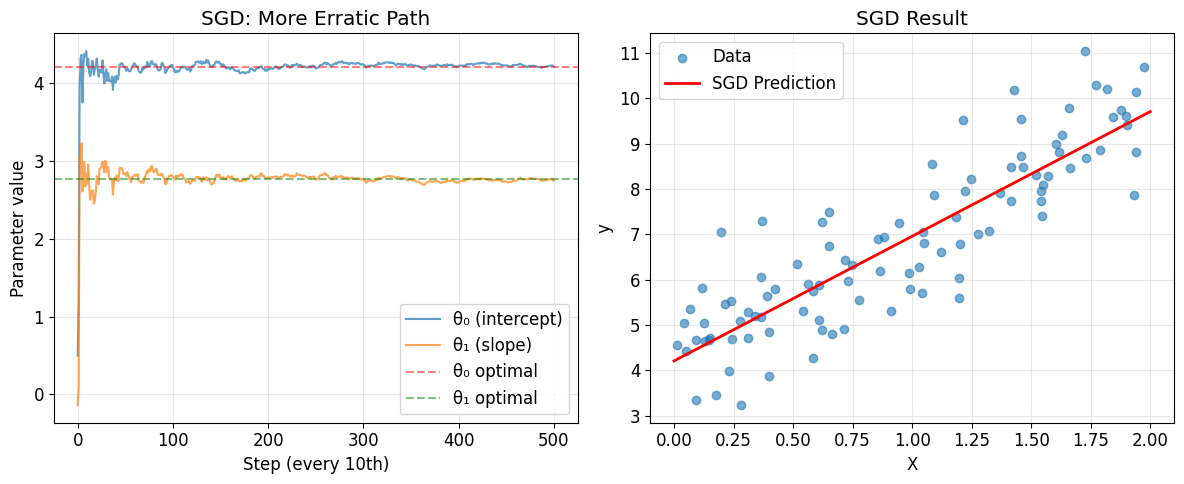

In [12]:
# Visualize SGD path (more erratic)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(theta_history_sgd[:, 0], alpha=0.7, label='θ₀ (intercept)')
plt.plot(theta_history_sgd[:, 1], alpha=0.7, label='θ₁ (slope)')
plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.5, label='θ₀ optimal')
plt.axhline(y=theta_best[1][0], color='g', linestyle='--', alpha=0.5, label='θ₁ optimal')
plt.xlabel('Step (every 10th)')
plt.ylabel('Parameter value')
plt.title('SGD: More Erratic Path')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label="Data")
y_predict_sgd = X_new_b.dot(theta)
plt.plot(X_new, y_predict_sgd, "r-", linewidth=2, label="SGD Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("SGD Result")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Using Scikit-Learn's SGDRegressor

In [13]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel())

print("SGDRegressor results:")
print(f"Intercept (θ₀): {sgd_reg.intercept_[0]:.4f}")
print(f"Coefficient (θ₁): {sgd_reg.coef_[0]:.4f}")

SGDRegressor results:
Intercept (θ₀): 4.2437
Coefficient (θ₁): 2.8251


---
## 3.3 Mini-batch Gradient Descent

### Theory
Computes gradients on small random sets of instances (mini-batches).

**Advantages:**
- Middle ground between Batch and Stochastic GD
- Performance boost from hardware optimization (GPUs)
- Less erratic than SGD
- Better than Batch GD for large datasets

In [14]:
# Mini-batch Gradient Descent implementation
n_epochs = 50
batch_size = 20
n_batches = m // batch_size

np.random.seed(42)
theta = np.random.randn(2, 1)
theta_history_minibatch = [theta.copy()]

t0, t1 = 200, 1000

for epoch in range(n_epochs):
    # Shuffle data at the beginning of each epoch
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    for i in range(0, m, batch_size):
        # Get mini-batch
        xi = X_b_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        
        # Compute gradient on mini-batch
        gradients = 2/batch_size * xi.T.dot(xi.dot(theta) - yi)
        
        # Update with learning schedule
        eta = learning_schedule(epoch * n_batches + i//batch_size)
        theta = theta - eta * gradients
        theta_history_minibatch.append(theta.copy())

theta_history_minibatch = np.array(theta_history_minibatch)

print("Mini-batch Gradient Descent results:")
print(f"θ₀ (intercept): {theta[0][0]:.4f}")
print(f"θ₁ (slope): {theta[1][0]:.4f}")
print(f"\nBatch size: {batch_size}")
print(f"Number of batches per epoch: {n_batches}")

Mini-batch Gradient Descent results:
θ₀ (intercept): 4.2522
θ₁ (slope): 2.7897

Batch size: 20
Number of batches per epoch: 5


### Comparison of All Three Methods

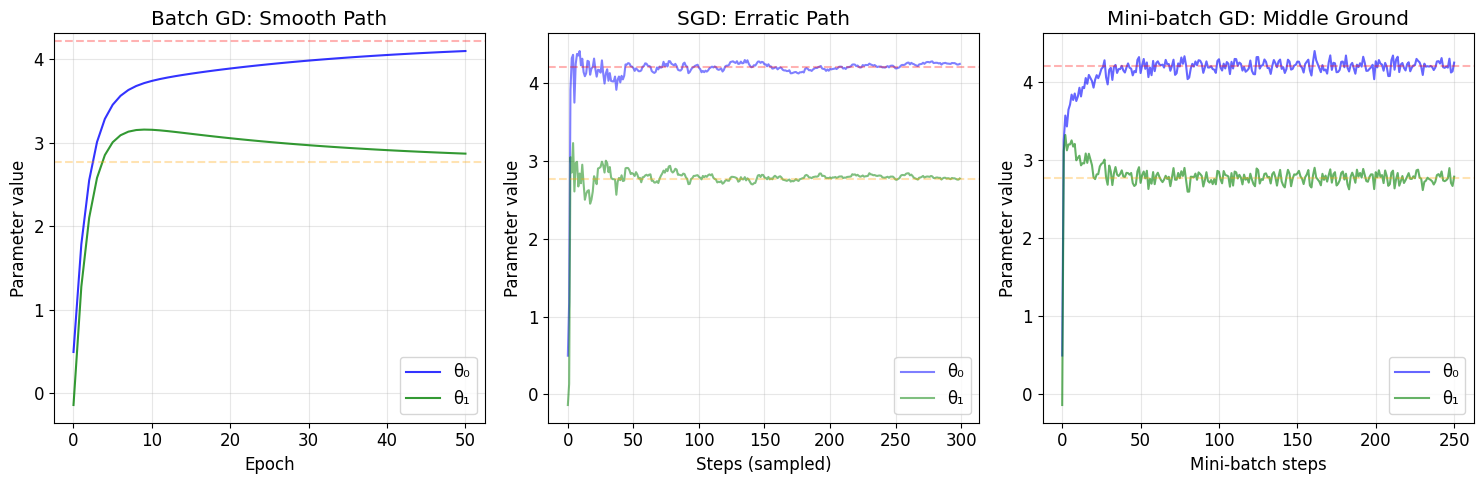


=== Comparison Summary ===
Batch GD     : θ₀=4.1001, θ₁=2.8717
Stochastic GD: θ₀=4.2155, θ₁=2.7513
Mini-batch GD: θ₀=4.2522, θ₁=2.7897
Optimal      : θ₀=4.2151, θ₁=2.7701


In [15]:
# Compare all three gradient descent variants
plt.figure(figsize=(15, 5))

# Rerun Batch GD with fewer iterations for fair comparison
np.random.seed(42)
theta_batch = np.random.randn(2, 1)
theta_hist_batch = [theta_batch.copy()]
eta_batch = 0.1

for _ in range(50):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta_batch) - y)
    theta_batch = theta_batch - eta_batch * gradients
    theta_hist_batch.append(theta_batch.copy())

theta_hist_batch = np.array(theta_hist_batch)

# Plot comparison
plt.subplot(1, 3, 1)
plt.plot(theta_hist_batch[:, 0], 'b-', alpha=0.8, label='θ₀')
plt.plot(theta_hist_batch[:, 1], 'g-', alpha=0.8, label='θ₁')
plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.3)
plt.axhline(y=theta_best[1][0], color='orange', linestyle='--', alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Parameter value')
plt.title('Batch GD: Smooth Path')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(theta_history_sgd[:300, 0], 'b-', alpha=0.5, label='θ₀')
plt.plot(theta_history_sgd[:300, 1], 'g-', alpha=0.5, label='θ₁')
plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.3)
plt.axhline(y=theta_best[1][0], color='orange', linestyle='--', alpha=0.3)
plt.xlabel('Steps (sampled)')
plt.ylabel('Parameter value')
plt.title('SGD: Erratic Path')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(theta_history_minibatch[:, 0], 'b-', alpha=0.6, label='θ₀')
plt.plot(theta_history_minibatch[:, 1], 'g-', alpha=0.6, label='θ₁')
plt.axhline(y=theta_best[0][0], color='r', linestyle='--', alpha=0.3)
plt.axhline(y=theta_best[1][0], color='orange', linestyle='--', alpha=0.3)
plt.xlabel('Mini-batch steps')
plt.ylabel('Parameter value')
plt.title('Mini-batch GD: Middle Ground')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Comparison Summary ===")
print(f"Batch GD     : θ₀={theta_hist_batch[-1][0][0]:.4f}, θ₁={theta_hist_batch[-1][1][0]:.4f}")
print(f"Stochastic GD: θ₀={theta_history_sgd[-1][0][0]:.4f}, θ₁={theta_history_sgd[-1][1][0]:.4f}")
print(f"Mini-batch GD: θ₀={theta_history_minibatch[-1][0][0]:.4f}, θ₁={theta_history_minibatch[-1][1][0]:.4f}")
print(f"Optimal      : θ₀={theta_best[0][0]:.4f}, θ₁={theta_best[1][0]:.4f}")

### Algorithm Comparison Table

| Algorithm | Large m | Out-of-core | Large n | Hyperparams | Scaling Required |
|-----------|---------|-------------|---------|-------------|------------------|
| Normal Equation | Fast | No | Slow | 0 | No |
| Batch GD | Slow | No | Fast | 2 | Yes |
| Stochastic GD | Fast | Yes | Fast | ≥2 | Yes |
| Mini-batch GD | Fast | Yes | Fast | ≥2 | Yes |

---
## 4. Polynomial Regression

### Theory
When data is nonlinear, we can use **Polynomial Regression** by adding powers of features as new features.

For example, to fit a quadratic relationship:
$$y = \theta_0 + \theta_1 x + \theta_2 x^2$$

We transform the feature $x$ into $[x, x^2]$ and then use Linear Regression.

**Warning:** Features grow combinatorially! For $n$ features and degree $d$:
$$\text{Number of features} = \frac{(n+d)!}{d! \cdot n!}$$

### Generate Nonlinear Data

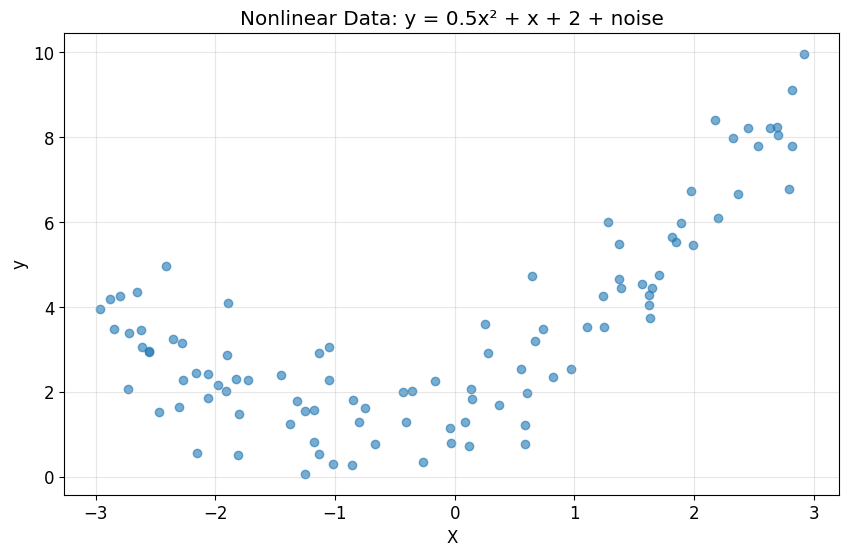

Generated 100 quadratic data points
True relationship: y = 0.5x² + x + 2


In [16]:
# Generate quadratic data: y = 0.5x² + x + 2 + noise
np.random.seed(42)
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3  # X values between -3 and 3
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(m, 1)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_poly, y_poly, alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Nonlinear Data: y = 0.5x² + x + 2 + noise")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Generated {m} quadratic data points")
print(f"True relationship: y = 0.5x² + x + 2")

### Attempt 1: Linear Regression (Underfitting)

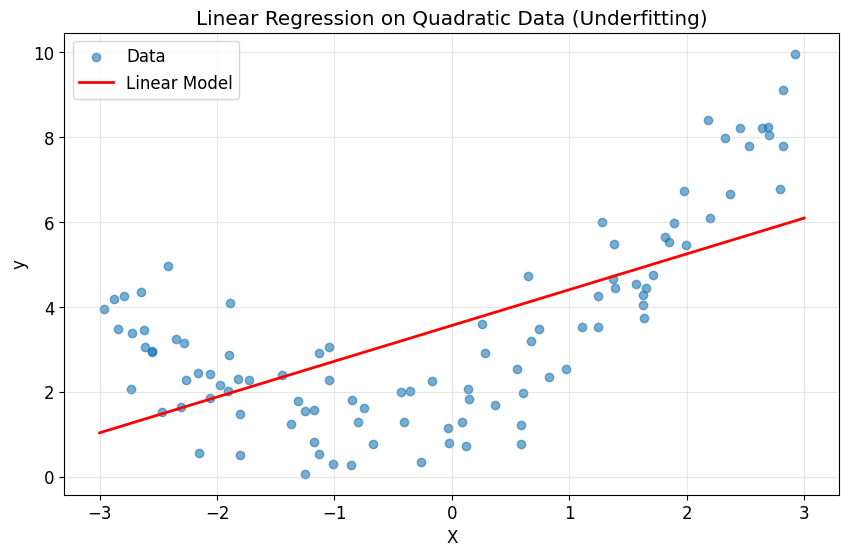

Linear model (underfits the quadratic data):
Intercept: 3.5640
Coefficient: 0.8436


In [17]:
# Try fitting with simple Linear Regression
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y_poly)

# Make predictions
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_pred_linear = lin_reg_poly.predict(X_plot)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_poly, y_poly, alpha=0.6, label="Data")
plt.plot(X_plot, y_pred_linear, "r-", linewidth=2, label="Linear Model")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression on Quadratic Data (Underfitting)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Linear model (underfits the quadratic data):")
print(f"Intercept: {lin_reg_poly.intercept_[0]:.4f}")
print(f"Coefficient: {lin_reg_poly.coef_[0][0]:.4f}")

### Attempt 2: Polynomial Regression (Good Fit)

In [18]:
# Use PolynomialFeatures to add polynomial terms
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_transformed = poly_features.fit_transform(X_poly)

print("Original feature shape:", X_poly.shape)
print("Transformed feature shape:", X_poly_transformed.shape)
print("\nExample transformation:")
print(f"X[0] = {X_poly[0]}")
print(f"X_poly[0] = {X_poly_transformed[0]}  # [x, x²]")

# Fit linear regression on polynomial features
lin_reg_poly2 = LinearRegression()
lin_reg_poly2.fit(X_poly_transformed, y_poly)

print(f"\nModel: ŷ = {lin_reg_poly2.intercept_[0]:.4f} + {lin_reg_poly2.coef_[0][0]:.4f}x + {lin_reg_poly2.coef_[0][1]:.4f}x²")
print(f"Expected: ŷ ≈ 2 + 1x + 0.5x²")

Original feature shape: (100, 1)
Transformed feature shape: (100, 2)

Example transformation:
X[0] = [-0.75275929]
X_poly[0] = [-0.75275929  0.56664654]  # [x, x²]

Model: ŷ = 1.7813 + 0.9337x + 0.5646x²
Expected: ŷ ≈ 2 + 1x + 0.5x²


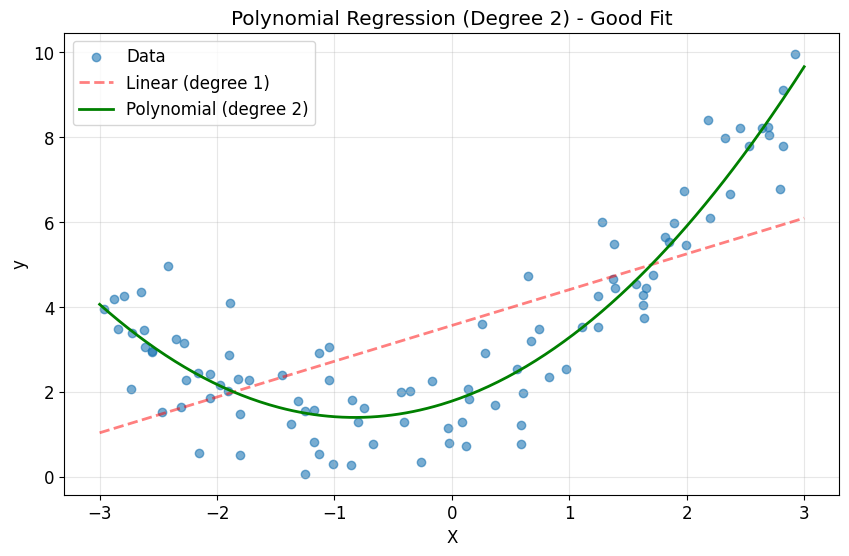

In [19]:
# Make predictions
X_plot_poly = poly_features.transform(X_plot)
y_pred_poly2 = lin_reg_poly2.predict(X_plot_poly)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_poly, y_poly, alpha=0.6, label="Data")
plt.plot(X_plot, y_pred_linear, "r--", linewidth=2, label="Linear (degree 1)", alpha=0.5)
plt.plot(X_plot, y_pred_poly2, "g-", linewidth=2, label="Polynomial (degree 2)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 2) - Good Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Attempt 3: High-Degree Polynomial (Overfitting)

Degree 10 polynomial has 10 features!


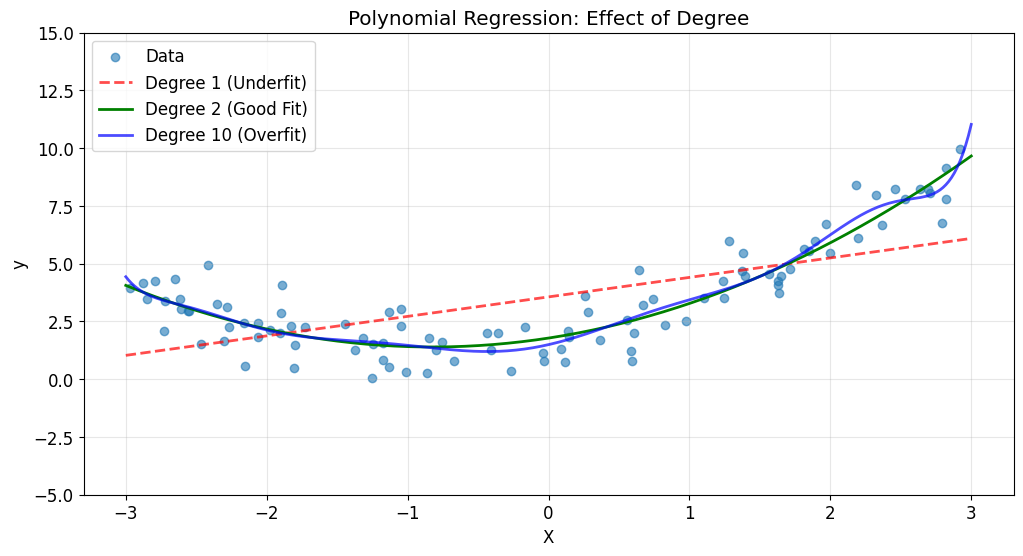

In [20]:
# Try degree 10 polynomial
poly_features_10 = PolynomialFeatures(degree=10, include_bias=False)
X_poly_10 = poly_features_10.fit_transform(X_poly)

lin_reg_poly10 = LinearRegression()
lin_reg_poly10.fit(X_poly_10, y_poly)

# Predictions
X_plot_poly10 = poly_features_10.transform(X_plot)
y_pred_poly10 = lin_reg_poly10.predict(X_plot_poly10)

print(f"Degree 10 polynomial has {X_poly_10.shape[1]} features!")

# Compare all three
plt.figure(figsize=(12, 6))
plt.scatter(X_poly, y_poly, alpha=0.6, label="Data")
plt.plot(X_plot, y_pred_linear, "r--", linewidth=2, label="Degree 1 (Underfit)", alpha=0.7)
plt.plot(X_plot, y_pred_poly2, "g-", linewidth=2, label="Degree 2 (Good Fit)")
plt.plot(X_plot, y_pred_poly10, "b-", linewidth=2, label="Degree 10 (Overfit)", alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression: Effect of Degree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-5, 15)
plt.show()

---
## 5. Learning Curves

### Theory
Learning curves plot model performance on training and validation sets as a function of training set size.

They help detect:
- **Underfitting (High Bias):** Both curves plateau at high error, close together
- **Overfitting (High Variance):** Large gap between curves

### Helper Function

In [21]:
def plot_learning_curves(model, X, y, title="Learning Curves"):
    """
    Plot learning curves for a model
    """
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    train_errors, val_errors = [], []
    
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    
    plt.figure(figsize=(10, 6))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Training set")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation set")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.show()

print("Learning curve helper function defined!")

Learning curve helper function defined!


### Example 1: Underfitting Model (Linear on Quadratic Data)

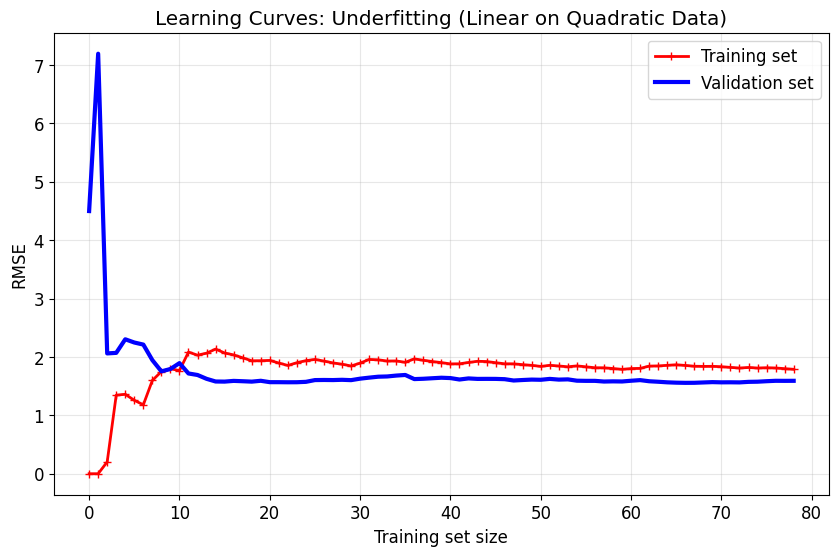

Notice: Both curves plateau at high error → Underfitting (High Bias)
Solution: Use more complex model or better features


In [22]:
# Linear model on quadratic data (underfits)
lin_reg_underfit = LinearRegression()
plot_learning_curves(lin_reg_underfit, X_poly, y_poly, 
                    title="Learning Curves: Underfitting (Linear on Quadratic Data)")

print("Notice: Both curves plateau at high error → Underfitting (High Bias)")
print("Solution: Use more complex model or better features")

### Example 2: Overfitting Model (High-Degree Polynomial)

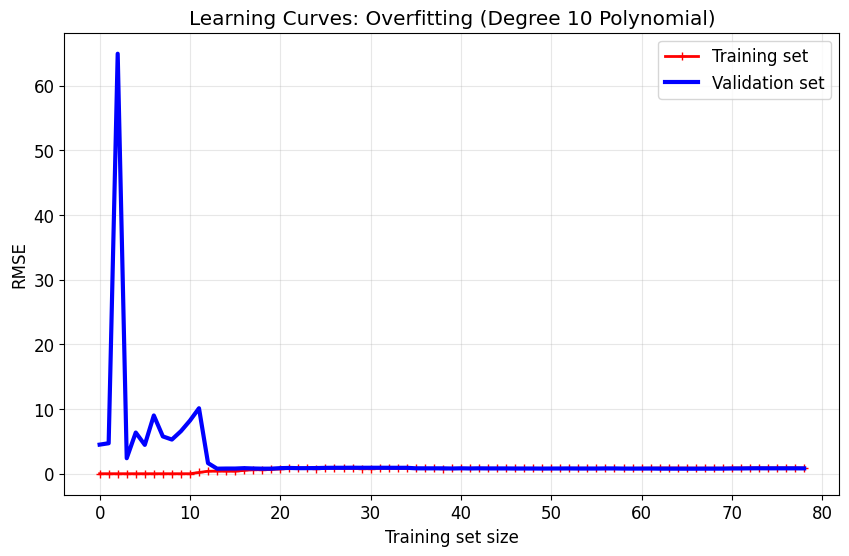

Notice: Large gap between curves → Overfitting (High Variance)
Training error is low, validation error is high
Solution: More training data, simpler model, or regularization


In [23]:
# High-degree polynomial (overfits)
pipeline_poly10 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin_reg", LinearRegression())
])

plot_learning_curves(pipeline_poly10, X_poly, y_poly, 
                    title="Learning Curves: Overfitting (Degree 10 Polynomial)")

print("Notice: Large gap between curves → Overfitting (High Variance)")
print("Training error is low, validation error is high")
print("Solution: More training data, simpler model, or regularization")

---
## 6. Bias/Variance Trade-off

### Theory
**Generalization Error = Bias + Variance + Irreducible Error**

1. **Bias:** Error from wrong assumptions
   - High bias → Underfitting
   - Model too simple to capture data patterns

2. **Variance:** Error from sensitivity to training data variations
   - High variance → Overfitting
   - Model too complex, memorizes training data

3. **Irreducible Error:** From data noise
   - Can't be reduced by model improvements

**Trade-off:** Increasing model complexity typically:
- ↑ Variance (more sensitive to data)
- ↓ Bias (better at capturing patterns)

---
## 7. Regularized Linear Models

Regularization constrains the model to reduce overfitting by penalizing large weights.

### 7.1 Ridge Regression (ℓ2 Regularization)

**Cost Function:**
$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_i^2$$

**Closed-form Solution:**
$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X} + \alpha \mathbf{A})^{-1} \mathbf{X}^T \mathbf{y}$$

Where:
- $\alpha$ = regularization strength
  - $\alpha = 0$: Regular Linear Regression
  - Large $\alpha$: Weights → 0, nearly flat line
- $\mathbf{A}$ = identity matrix (bias not regularized)

**Important:** Always scale features before using Ridge!

In [24]:
# Prepare scaled polynomial features
np.random.seed(42)
m = 20  # Smaller dataset to show overfitting
X_ridge = 6 * np.random.rand(m, 1) - 3
y_ridge = 0.5 * X_ridge**2 + X_ridge + 2 + np.random.randn(m, 1)

# Create polynomial features and scale
poly_ridge = PolynomialFeatures(degree=10, include_bias=False)
X_ridge_poly = poly_ridge.fit_transform(X_ridge)

scaler = StandardScaler()
X_ridge_poly_scaled = scaler.fit_transform(X_ridge_poly)

print(f"Training with {m} samples")
print(f"Original features: {X_ridge.shape[1]}")
print(f"Polynomial features (degree 10): {X_ridge_poly.shape[1]}")

Training with 20 samples
Original features: 1
Polynomial features (degree 10): 10


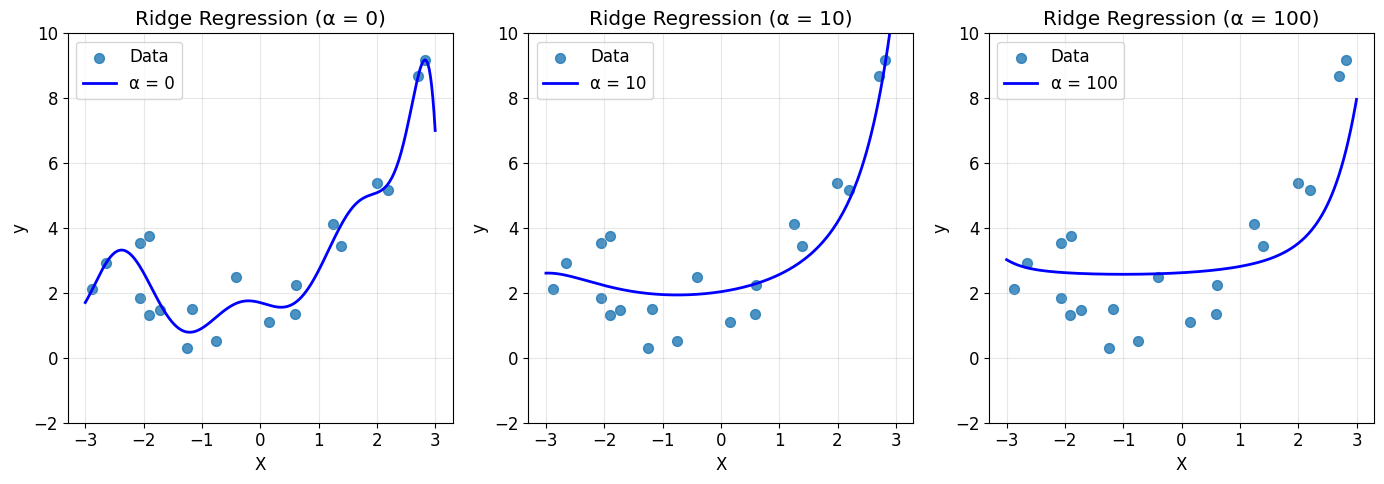

Effect of α:
- α = 0: No regularization (overfits)
- α = 10: Moderate regularization (good balance)
- α = 100: Strong regularization (underfits)


In [25]:
# Compare different alpha values for Ridge
alphas = [0, 10, 100]
X_plot_ridge = np.linspace(-3, 3, 300).reshape(-1, 1)
X_plot_ridge_poly = poly_ridge.transform(X_plot_ridge)
X_plot_ridge_poly_scaled = scaler.transform(X_plot_ridge_poly)

plt.figure(figsize=(14, 5))

for idx, alpha in enumerate(alphas, 1):
    plt.subplot(1, 3, idx)
    
    ridge_reg = Ridge(alpha=alpha, solver="cholesky", random_state=42)
    ridge_reg.fit(X_ridge_poly_scaled, y_ridge)
    
    y_pred_ridge = ridge_reg.predict(X_plot_ridge_poly_scaled)
    
    plt.scatter(X_ridge, y_ridge, alpha=0.8, s=50, label="Data")
    plt.plot(X_plot_ridge, y_pred_ridge, "b-", linewidth=2, label=f"α = {alpha}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Ridge Regression (α = {alpha})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-2, 10)

plt.tight_layout()
plt.show()

print("Effect of α:")
print("- α = 0: No regularization (overfits)")
print("- α = 10: Moderate regularization (good balance)")
print("- α = 100: Strong regularization (underfits)")

### 7.2 Lasso Regression (ℓ1 Regularization)

**Cost Function:**
$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^{n} |\theta_i|$$

**Key Feature:** Tends to eliminate weights of least important features (sets them to zero).
- Performs **automatic feature selection**
- Produces **sparse models** (many weights = 0)

**Subgradient for Gradient Descent:**
$$\text{sign}(\theta_i) = \begin{cases} -1 & \text{if } \theta_i < 0 \\ 0 & \text{if } \theta_i = 0 \\ +1 & \text{if } \theta_i > 0 \end{cases}$$

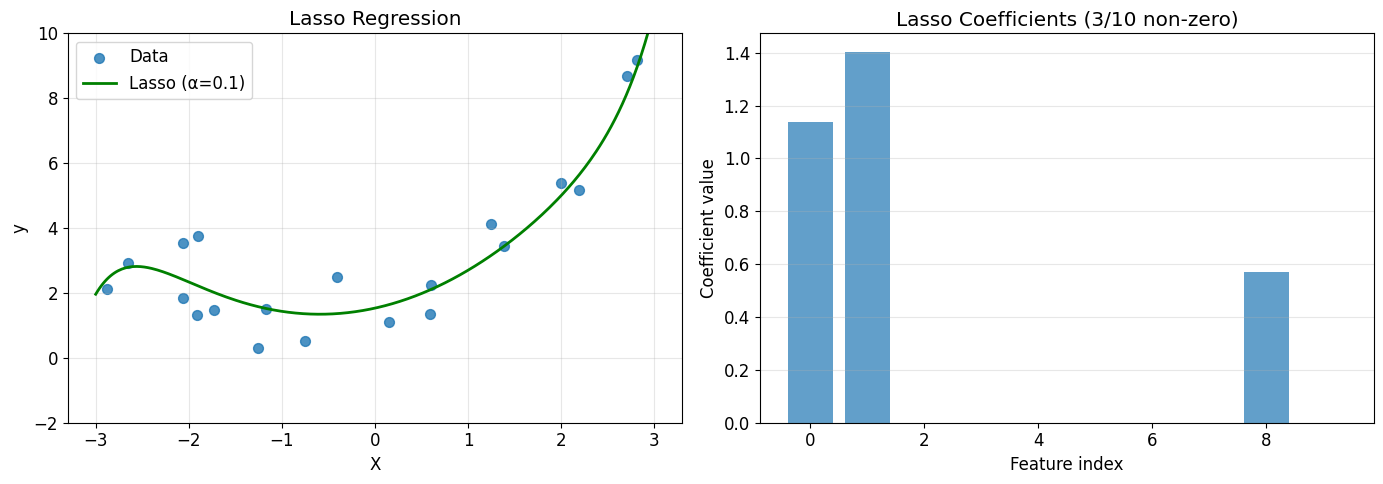

Lasso set 7 coefficients to zero
Non-zero coefficients: 3 out of 10
→ Automatic feature selection!


In [26]:
# Lasso Regression
lasso_reg = Lasso(alpha=0.1, random_state=42)
lasso_reg.fit(X_ridge_poly_scaled, y_ridge)

y_pred_lasso = lasso_reg.predict(X_plot_ridge_poly_scaled)

# Count non-zero coefficients
non_zero_coefs = np.sum(lasso_reg.coef_ != 0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_ridge, y_ridge, alpha=0.8, s=50, label="Data")
plt.plot(X_plot_ridge, y_pred_lasso, "g-", linewidth=2, label="Lasso (α=0.1)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Lasso Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-2, 10)

plt.subplot(1, 2, 2)
plt.bar(range(len(lasso_reg.coef_)), lasso_reg.coef_, alpha=0.7)
plt.xlabel("Feature index")
plt.ylabel("Coefficient value")
plt.title(f"Lasso Coefficients ({non_zero_coefs}/{len(lasso_reg.coef_)} non-zero)")
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Lasso set {len(lasso_reg.coef_) - non_zero_coefs} coefficients to zero")
print(f"Non-zero coefficients: {non_zero_coefs} out of {len(lasso_reg.coef_)}")
print("→ Automatic feature selection!")

### 7.3 Elastic Net

**Cost Function:**
$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + r\alpha \sum_{i=1}^{n} |\theta_i| + \frac{(1-r)}{2}\alpha \sum_{i=1}^{n} \theta_i^2$$

Combines Ridge and Lasso:
- $r = 0$: Pure Ridge Regression
- $r = 1$: Pure Lasso Regression
- $0 < r < 1$: Mix of both

**Preferred over Lasso:** More stable when features are correlated or many features exist.

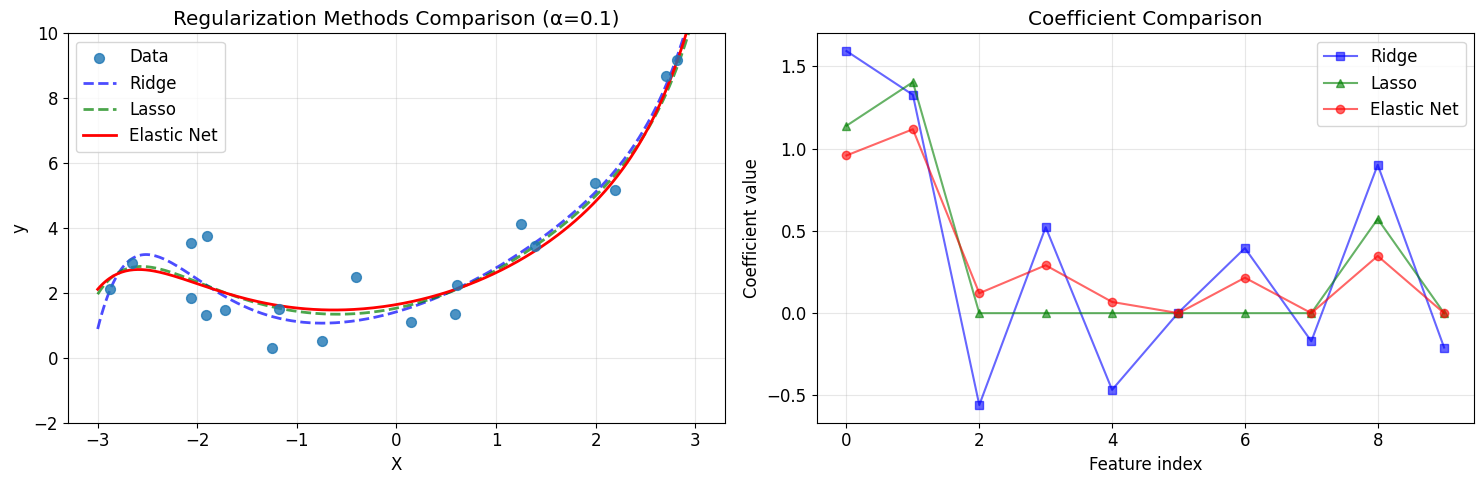

Regularization Summary:
Ridge: All 10 coefficients non-zero (shrinks but keeps all)
Lasso: 3 non-zero coefficients (feature selection)
Elastic Net: 7 non-zero coefficients (balance)


In [27]:
# Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X_ridge_poly_scaled, y_ridge)

y_pred_elastic = elastic_net.predict(X_plot_ridge_poly_scaled)

# Compare all three regularization methods
plt.figure(figsize=(15, 5))

ridge_reg_compare = Ridge(alpha=0.1, random_state=42)
ridge_reg_compare.fit(X_ridge_poly_scaled, y_ridge)
y_pred_ridge_compare = ridge_reg_compare.predict(X_plot_ridge_poly_scaled)

lasso_reg_compare = Lasso(alpha=0.1, random_state=42)
lasso_reg_compare.fit(X_ridge_poly_scaled, y_ridge)
y_pred_lasso_compare = lasso_reg_compare.predict(X_plot_ridge_poly_scaled)

# Plot predictions
plt.subplot(1, 2, 1)
plt.scatter(X_ridge, y_ridge, alpha=0.8, s=50, label="Data", zorder=3)
plt.plot(X_plot_ridge, y_pred_ridge_compare, "b--", linewidth=2, label="Ridge", alpha=0.7)
plt.plot(X_plot_ridge, y_pred_lasso_compare, "g--", linewidth=2, label="Lasso", alpha=0.7)
plt.plot(X_plot_ridge, y_pred_elastic, "r-", linewidth=2, label="Elastic Net")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regularization Methods Comparison (α=0.1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-2, 10)

# Plot coefficients
plt.subplot(1, 2, 2)
x_axis = range(len(ridge_reg_compare.coef_))
plt.plot(x_axis, ridge_reg_compare.coef_, "bs-", label="Ridge", alpha=0.6)
plt.plot(x_axis, lasso_reg_compare.coef_, "g^-", label="Lasso", alpha=0.6)
plt.plot(x_axis, elastic_net.coef_, "ro-", label="Elastic Net", alpha=0.6)
plt.xlabel("Feature index")
plt.ylabel("Coefficient value")
plt.title("Coefficient Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Regularization Summary:")
print(f"Ridge: All {np.sum(ridge_reg_compare.coef_ != 0)} coefficients non-zero (shrinks but keeps all)")
print(f"Lasso: {np.sum(lasso_reg_compare.coef_ != 0)} non-zero coefficients (feature selection)")
print(f"Elastic Net: {np.sum(elastic_net.coef_ != 0)} non-zero coefficients (balance)")

### When to Use Which Regularization?

| Method | When to Use |
|--------|-------------|
| **Ridge** | Good default; use when most features are useful |
| **Lasso** | When only few features are useful (feature selection) |
| **Elastic Net** | Preferred over Lasso (more stable with many/correlated features) |

---
## 8. Early Stopping

### Theory
Stop training when validation error reaches minimum, preventing overfitting.

**Geoffrey Hinton:** Called it a "beautiful free lunch"

**Process:**
1. Train model iteratively (e.g., with SGD)
2. Monitor validation error at each epoch
3. Stop when validation error stops improving
4. Roll back to best model

In [31]:
# Early Stopping Implementation
from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Prepare data with high-degree polynomial
np.random.seed(42)
m = 100
X_early = 6 * np.random.rand(m, 1) - 3
y_early = 0.5 * X_early**2 + X_early + 2 + np.random.randn(m, 1)

# Split data
X_train, X_val, y_train, y_val = train_test_split(X_early, y_early, test_size=0.2, random_state=42)

# Create polynomial features and scale
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler())
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

# SGD with warm_start for early stopping
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

minimum_val_error = float("inf")
best_epoch = None
best_model = None
train_errors = []
val_errors = []

for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train.ravel())  # continues where it left off
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    
    # Track errors
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    train_error = mean_squared_error(y_train, y_train_predict)
    train_errors.append(train_error)
    val_errors.append(val_error)
    
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

print(f"Best epoch: {best_epoch}")
print(f"Minimum validation error: {minimum_val_error:.4f}")

Best epoch: 7
Minimum validation error: 12.9078


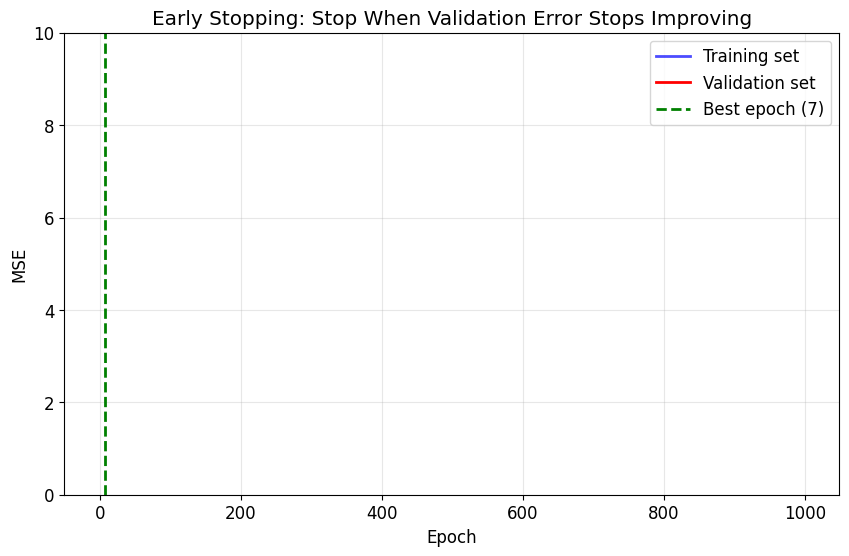

\nStopped at epoch 7 instead of running all 1000 epochs
Prevented overfitting by monitoring validation error!


In [32]:
# Visualize early stopping
plt.figure(figsize=(10, 6))
plt.plot(train_errors, "b-", linewidth=2, label="Training set", alpha=0.7)
plt.plot(val_errors, "r-", linewidth=2, label="Validation set")
plt.axvline(x=best_epoch, color='g', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Early Stopping: Stop When Validation Error Stops Improving")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(min(train_errors[-1], 10), min(val_errors[-1], 10)))
plt.show()

print(f"\\nStopped at epoch {best_epoch} instead of running all 1000 epochs")
print("Prevented overfitting by monitoring validation error!")

---
## 9. Logistic Regression

### Theory
Estimates the probability that an instance belongs to a particular class (binary classification).

**Model:**
$$\hat{p} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \sigma(\mathbf{x}^T\boldsymbol{\theta})$$

**Sigmoid (Logistic) Function:**
$$\sigma(t) = \frac{1}{1 + \exp(-t)}$$

Properties:
- Outputs values between 0 and 1
- S-shaped curve
- $\sigma(t) \geq 0.5$ when $t \geq 0$

**Prediction:**
$$\hat{y} = \begin{cases} 0 & \text{if } \hat{p} < 0.5 \\ 1 & \text{if } \hat{p} \geq 0.5 \end{cases}$$

**Cost Function (Log Loss / Cross Entropy):**
$$J(\boldsymbol{\theta}) = -\frac{1}{m} \sum_{i=1}^{m} \left[y^{(i)} \log(\hat{p}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)})\right]$$

**Note:** Convex function → Gradient Descent finds global minimum

### Visualize Sigmoid Function

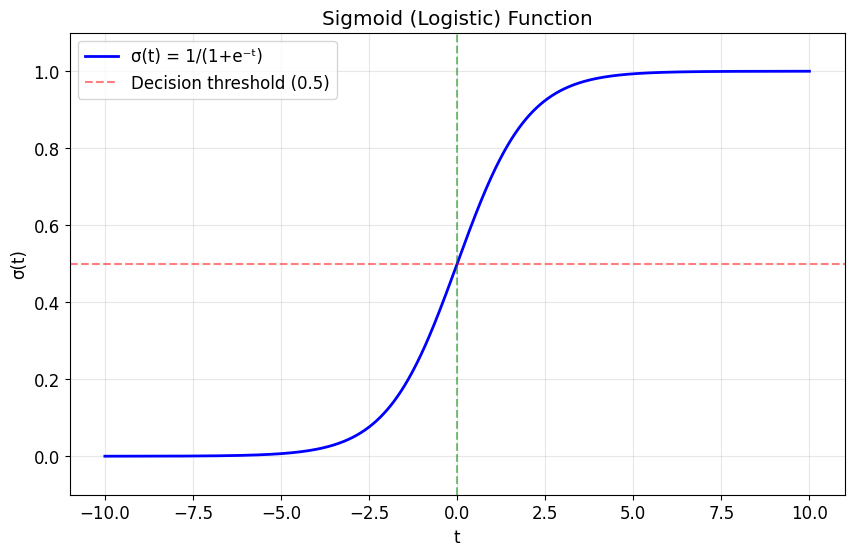

Key properties:
σ(0) = 0.5000
σ(-5) = 0.0067
σ(5) = 0.9933
\nOutputs are always between 0 and 1 (probabilities!)


In [33]:
# Sigmoid function
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

t = np.linspace(-10, 10, 1000)
y_sigmoid = sigmoid(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y_sigmoid, 'b-', linewidth=2, label='σ(t) = 1/(1+e⁻ᵗ)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision threshold (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5)
plt.xlabel("t")
plt.ylabel("σ(t)")
plt.title("Sigmoid (Logistic) Function")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

print("Key properties:")
print(f"σ(0) = {sigmoid(0):.4f}")
print(f"σ(-5) = {sigmoid(-5):.4f}")
print(f"σ(5) = {sigmoid(5):.4f}")
print("\\nOutputs are always between 0 and 1 (probabilities!)")

### Example: Iris Virginica Detection (Single Feature)

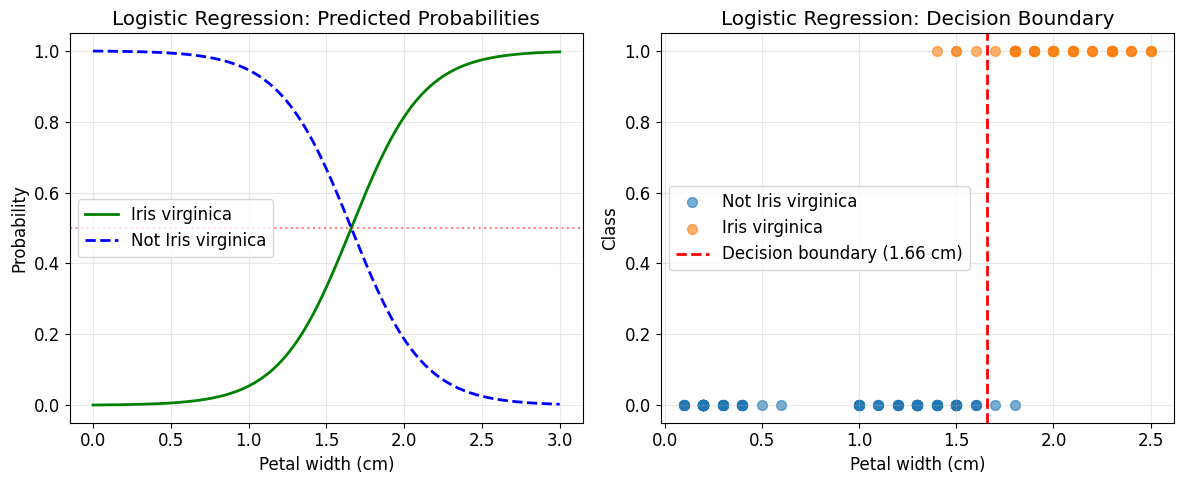

Predictions:
Petal width 1.5 cm: Class 0, P(virginica)=0.333
Petal width 1.7 cm: Class 1, P(virginica)=0.543


In [34]:
# Load Iris dataset
iris = datasets.load_iris()
X_iris = iris["data"][:, 3:]  # petal width only
y_iris = (iris["target"] == 2).astype(np.int64)  # 1 if Iris virginica, else 0

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_iris, y_iris)

# Make predictions
X_new_iris = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new_iris)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(X_new_iris, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new_iris, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")
plt.axhline(y=0.5, color='r', linestyle=':', alpha=0.5)
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.title("Logistic Regression: Predicted Probabilities")
plt.legend(loc="center left")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot decision boundary
decision_boundary = X_new_iris[y_proba[:, 1] >= 0.5][0]
plt.scatter(X_iris[y_iris==0], y_iris[y_iris==0], alpha=0.6, label="Not Iris virginica", s=50)
plt.scatter(X_iris[y_iris==1], y_iris[y_iris==1], alpha=0.6, label="Iris virginica", s=50)
plt.axvline(x=decision_boundary, color='r', linestyle='--', linewidth=2, label=f'Decision boundary ({decision_boundary[0]:.2f} cm)')
plt.xlabel("Petal width (cm)")
plt.ylabel("Class")
plt.title("Logistic Regression: Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test predictions
test_widths = np.array([[1.5], [1.7]])
predictions = log_reg.predict(test_widths)
probabilities = log_reg.predict_proba(test_widths)

print("Predictions:")
for width, pred, proba in zip(test_widths, predictions, probabilities):
    print(f"Petal width {width[0]} cm: Class {pred}, P(virginica)={proba[1]:.3f}")

### Example: Multi-Feature Logistic Regression

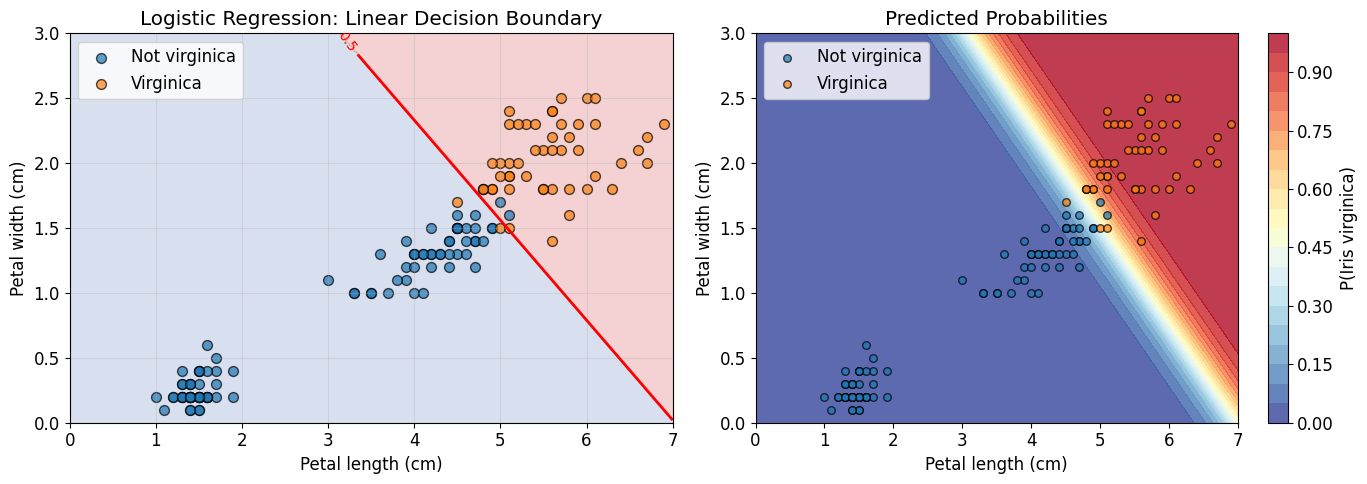

Model coefficients: [[4.42127497 5.73969187]]
Model intercept: [-31.06493254]
\nDecision boundary is linear!


In [35]:
# Use petal length and width
X_iris_2d = iris["data"][:, (2, 3)]  # petal length, petal width
y_iris_2d = (iris["target"] == 2).astype(np.int64)

log_reg_2d = LogisticRegression(C=10, random_state=42)
log_reg_2d.fit(X_iris_2d, y_iris_2d)

# Create meshgrid for decision boundary
x0, x1 = np.meshgrid(
    np.linspace(0, 7, 500).reshape(-1, 1),
    np.linspace(0, 3, 200).reshape(-1, 1),
)
X_new_2d = np.c_[x0.ravel(), x1.ravel()]
y_proba_2d = log_reg_2d.predict_proba(X_new_2d)
y_predict_2d = log_reg_2d.predict(X_new_2d)

zz = y_proba_2d[:, 1].reshape(x0.shape)
zz_predict = y_predict_2d.reshape(x0.shape)

# Visualize
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Decision regions
plt.contourf(x0, x1, zz_predict, alpha=0.2, cmap='RdYlBu_r')
# Probability contours
contour = plt.contour(x0, x1, zz, levels=[0.5], linewidths=2, colors='red')
plt.clabel(contour, inline=True, fontsize=10)
# Data points
plt.scatter(X_iris_2d[y_iris_2d==0, 0], X_iris_2d[y_iris_2d==0, 1], 
           alpha=0.7, label="Not virginica", s=50, edgecolors='k')
plt.scatter(X_iris_2d[y_iris_2d==1, 0], X_iris_2d[y_iris_2d==1, 1], 
           alpha=0.7, label="Virginica", s=50, edgecolors='k')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Logistic Regression: Linear Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Probability heatmap
im = plt.contourf(x0, x1, zz, levels=20, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(im, label='P(Iris virginica)')
plt.scatter(X_iris_2d[y_iris_2d==0, 0], X_iris_2d[y_iris_2d==0, 1], 
           alpha=0.7, label="Not virginica", s=30, edgecolors='k', linewidths=1)
plt.scatter(X_iris_2d[y_iris_2d==1, 0], X_iris_2d[y_iris_2d==1, 1], 
           alpha=0.7, label="Virginica", s=30, edgecolors='k', linewidths=1)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Predicted Probabilities")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Model coefficients: {log_reg_2d.coef_}")
print(f"Model intercept: {log_reg_2d.intercept_}")
print("\\nDecision boundary is linear!")

---
## 10. Softmax Regression (Multinomial Logistic Regression)

### Theory
Generalizes Logistic Regression to **multiple classes** (multiclass classification).

**Constraint:** Classes must be mutually exclusive (not multioutput).

**Score for class k:**
$$s_k(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\theta}^{(k)}$$

Each class has its own parameter vector $\boldsymbol{\theta}^{(k)}$.

**Softmax Function:**
$$\hat{p}_k = \sigma(\mathbf{s}(\mathbf{x}))_k = \frac{\exp(s_k(\mathbf{x}))}{\sum_{j=1}^{K} \exp(s_j(\mathbf{x}))}$$

Properties:
- Outputs probabilities that sum to 1
- $0 \leq \hat{p}_k \leq 1$ for all $k$

**Prediction:**
$$\hat{y} = \underset{k}{\text{argmax}} \, \hat{p}_k$$

Predicts the class with highest estimated probability.

**Cost Function (Cross Entropy):**
$$J(\boldsymbol{\Theta}) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{p}_k^{(i)})$$

### Example: Iris 3-Class Classification

Test sample: [5 2]
Predicted class: 2 (virginica)
\nClass probabilities:
  setosa: 0.0000
  versicolor: 0.0574
  virginica: 0.9426


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


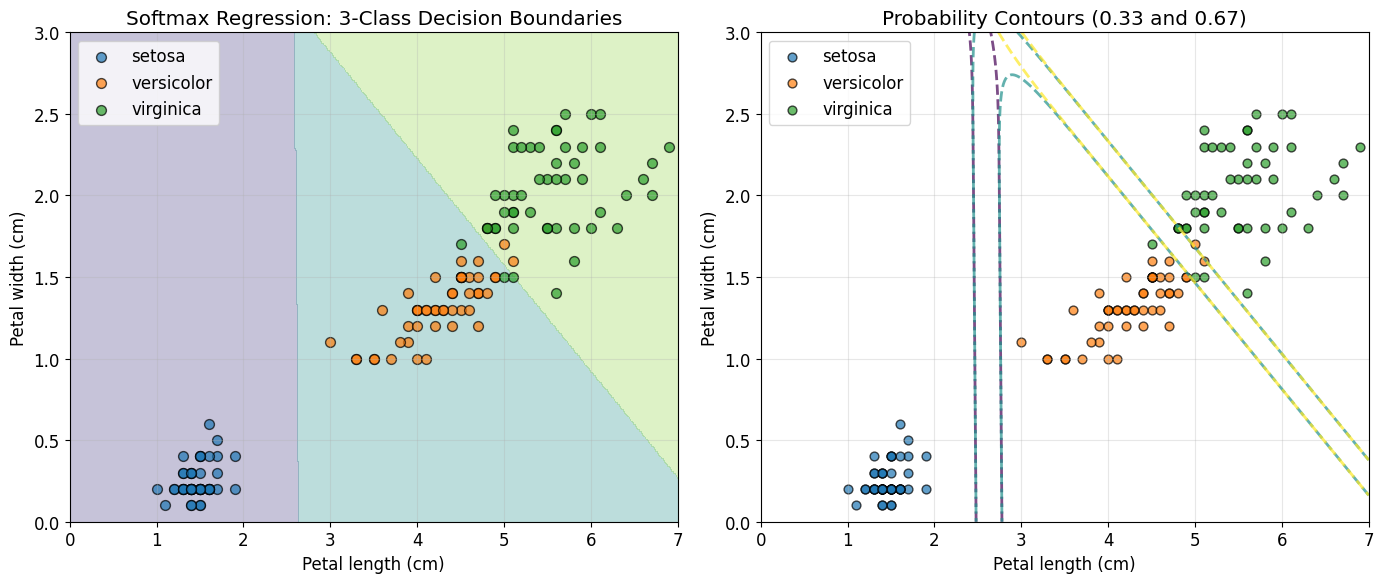

\nModel has 3 parameter vectors (one per class)
Each parameter vector has 2 coefficients (one per feature)


In [36]:
# Load full Iris dataset (3 classes)
X_softmax = iris["data"][:, (2, 3)]  # petal length, width
y_softmax = iris["target"]

# Train Softmax Regression
softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10, random_state=42)
softmax_reg.fit(X_softmax, y_softmax)

# Test prediction
test_sample = np.array([[5, 2]])
prediction = softmax_reg.predict(test_sample)
probabilities = softmax_reg.predict_proba(test_sample)

print("Test sample:", test_sample[0])
print(f"Predicted class: {prediction[0]} ({iris.target_names[prediction[0]]})")
print(f"\\nClass probabilities:")
for i, (name, prob) in enumerate(zip(iris.target_names, probabilities[0])):
    print(f"  {name}: {prob:.4f}")

# Visualize decision boundaries
x0_soft, x1_soft = np.meshgrid(
    np.linspace(0, 7, 500),
    np.linspace(0, 3, 200),
)
X_new_soft = np.c_[x0_soft.ravel(), x1_soft.ravel()]
y_proba_soft = softmax_reg.predict_proba(X_new_soft)
y_predict_soft = softmax_reg.predict(X_new_soft)

zz_soft = y_predict_soft.reshape(x0_soft.shape)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Decision regions
plt.contourf(x0_soft, x1_soft, zz_soft, alpha=0.3, cmap='viridis', levels=2)
# Data points
for class_id, class_name in enumerate(iris.target_names):
    plt.scatter(X_softmax[y_softmax==class_id, 0], 
               X_softmax[y_softmax==class_id, 1],
               alpha=0.7, label=class_name, s=50, edgecolors='k')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Softmax Regression: 3-Class Decision Boundaries")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show probability for each class
for i in range(3):
    zz_class = y_proba_soft[:, i].reshape(x0_soft.shape)
    plt.contour(x0_soft, x1_soft, zz_class, levels=[0.33, 0.67], 
               linewidths=2, linestyles='--', alpha=0.7, 
               colors=plt.cm.viridis(i/2))
    
# Plot data points
for class_id, class_name in enumerate(iris.target_names):
    plt.scatter(X_softmax[y_softmax==class_id, 0], 
               X_softmax[y_softmax==class_id, 1],
               alpha=0.7, label=class_name, s=40, edgecolors='k')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Probability Contours (0.33 and 0.67)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\\nModel has {len(softmax_reg.coef_)} parameter vectors (one per class)")
print(f"Each parameter vector has {len(softmax_reg.coef_[0])} coefficients (one per feature)")

---
## Summary and Key Takeaways

### Model Selection Guidelines

1. **Linear Regression:**
   - Few features (<100,000): Normal Equation or SVD
   - Many features or instances: Gradient Descent
   - Very large datasets: Stochastic or Mini-batch GD

2. **Regularization:**
   - Almost always use some regularization
   - **Ridge:** Good default when most features are useful
   - **Lasso:** When only few features are useful (feature selection)
   - **Elastic Net:** Preferred over Lasso (more stable)

3. **Polynomial Regression:**
   - Use for nonlinear data
   - Watch for overfitting with high degrees
   - Use learning curves to diagnose issues

4. **Classification:**
   - Binary: Logistic Regression
   - Multiclass (mutually exclusive): Softmax Regression
   - Always scale features before training

### Critical Practices

✅ **Always scale features** when using Gradient Descent or regularization  
✅ **Use learning curves** to diagnose bias/variance issues  
✅ **Apply early stopping** to prevent overfitting  
✅ **Shuffle data** for SGD to ensure IID instances  
✅ **Reduce learning rate gradually** for SGD/Mini-batch convergence  

### Computational Complexity

- **Normal Equation:** O(n²·⁴) to O(n³), linear in m
- **SVD:** O(n²), linear in m
- **Gradient Descent:** Fast with many features, scales well with m
- **Predictions:** Always fast, O(n × m)

### Bias/Variance Trade-off

**Generalization Error = Bias + Variance + Irreducible Error**

- ↑ Model complexity → ↓ Bias, ↑ Variance
- ↓ Model complexity → ↑ Bias, ↓ Variance
- Goal: Find optimal balance

---
## Exercises (From Chapter 4)

Try solving these on your own:

1. Which Linear Regression training algorithm can you use if you have a training set with millions of features?

2. Suppose the features in your training set have very different scales. Which algorithms might suffer from this, and how? What can you do about it?

3. Can Gradient Descent get stuck in a local minimum when training a Logistic Regression model?

4. Do all Gradient Descent algorithms lead to the same model, provided you let them run long enough?

5. Suppose you use Batch Gradient Descent and you plot the validation error at every epoch. If you notice that the validation error consistently goes up, what is likely going on? How can you fix this?

6. Is it a good idea to stop Mini-batch Gradient Descent immediately when the validation error goes up?

7. Which Gradient Descent algorithm (among those we discussed) will reach the vicinity of the optimal solution the fastest? Which will actually converge? How can you make the others converge as well?

8. Suppose you are using Polynomial Regression. You plot the learning curves and you notice that there is a large gap between the training error and the validation error. What is happening? What are three ways to solve this?

9. Suppose you are using Ridge Regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter α or reduce it?

10. Why would you want to use:
    - Ridge Regression instead of plain Linear Regression?
    - Lasso instead of Ridge Regression?
    - Elastic Net instead of Lasso?

11. Suppose you want to classify pictures as outdoor/indoor and daytime/nighttime. Should you implement two Logistic Regression classifiers or one Softmax Regression classifier?

---

**Congratulations!** 🎉 You've completed Chapter 4: Training Models!

You now understand:
- How Linear Regression works under the hood
- Different optimization algorithms (Normal Equation, Batch/Stochastic/Mini-batch GD)
- How to handle nonlinear data with Polynomial Regression
- How to diagnose and fix overfitting/underfitting
- Regularization techniques (Ridge, Lasso, Elastic Net)
- Binary classification with Logistic Regression
- Multiclass classification with Softmax Regression